# Support Ticket Clustering

In this notebook, we analyze a dataset of support tickets in order to create clusters, which will be assigned to the proper support team.

## Plan

Convert the tickets subject + body into embeddings to train a unsupervised clustering model. Thus, use a local use a local LLM to obtain a description per cluster as well as a TF-IDF analysis to extract representative keywords.

1. TF-IDF analysis for cleaning boilerplate and noise.

## Packages

In [25]:
# Data handling
import json
import re
from collections import Counter

import numpy as np
import pandas as pd

# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Plotting
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)

# Shared tokenizer pattern: accent-aware words of 2+ characters.
TOKEN_PATTERN = r"(?u)\b\w\w+\b"

## Dataset basic exploration

In [6]:
DATASET_PATH = 'dataset/classificacao_atendimento.csv'

tickets_df = pd.read_csv(DATASET_PATH, sep=',', encoding='utf-8')
tickets_df

,ticket_id,subject,body
0,2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es..."
1,28,Problemas intermitentes de exibição após atual...,"Caro Suporte ao Cliente,\n\n Estou entrando em..."
2,45,Pedido de Assistência para Administração de Se...,"Prezado Suporte ao Cliente de Serviços de TI,\..."
3,46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sob..."
4,63,Urgente: Relato de Falha na Bateria do MacBook...,"Prezado Atendimento ao Cliente,<br><br>Recente..."
...,...,...,...
468,3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que..."
469,3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEst..."
470,3988,Problema de Cobrança: Cobranças Incorretas na ...,"Caro Equipe de Suporte ao Cliente,\n\nEstou es..."
471,3994,Assistência Necessária para Problema de Tela d...,"Caro Time de Suporte ao Cliente, estou enfrent..."


Check whether the ticket ID column is unique. If yes, convert it to the Dataframe index.

In [8]:
tickets_df["ticket_id"].is_unique

True

The checking above confirms that the ticket_id is unique. Thus, let us convert this column to index.

In [11]:
tickets_df.set_index("ticket_id", inplace=True)
tickets_df

,subject,body
ticket_id,,
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es..."
28,Problemas intermitentes de exibição após atual...,"Caro Suporte ao Cliente,\n\n Estou entrando em..."
45,Pedido de Assistência para Administração de Se...,"Prezado Suporte ao Cliente de Serviços de TI,\..."
46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sob..."
63,Urgente: Relato de Falha na Bateria do MacBook...,"Prezado Atendimento ao Cliente,<br><br>Recente..."
...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que..."
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEst..."
3988,Problema de Cobrança: Cobranças Incorretas na ...,"Caro Equipe de Suporte ao Cliente,\n\nEstou es..."


Basic information

In [12]:
tickets_df.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 2 to 3996
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   subject  419 non-null    str  
 1   body     473 non-null    str  
dtypes: str(2)
memory usage: 11.1 KB


In [13]:
tickets_df.describe()

,subject,body
count,419,473
unique,419,473
top,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es..."
freq,1,1


## TF-IDF analysis for cleaning

Before embedding or clustering anything, we need to know — with evidence —
which parts of these tickets carry information about *what the customer needs*, and which parts are
noise repeated across multiple messages.

Any similarity measure treats shared text as evidence of similarity. Therefore, very frequent words such as `obrigado` and `atenciosamente` across the tickets buried the structure we are actually seeking.

The analysis proceeds in eight steps:

1. **Document preparation and chars/tokens analysis**
2. **Structural noise** — placeholders, HTML, and malformed rows
3. **Document frequency** — the core boilerplate detector, and the source of the stopword list
4. **N-gram analysis** — because the boilerplate here is phrasal, not lexical
5. **Positional analysis** — where boilerplate lives, and why that makes it safe to strip
6. **TF-IDF comparison** — whether vectorizer parameters alone can solve this
7. **Cleaning rules** — derived from the evidence above, with measured impact
8. **Qualitative validation** — confirm the signal survived

### 1. Document preparation and chars/tokens analysis

Build a single analysis field from `subject + body`. The two carry different information — subjects are
terse and almost purely topical, bodies contain the detail wrapped in email ceremony — but for measuring
corpus-wide boilerplate they should be treated as one document.

The original columns are left untouched, since the entire point of this section is a before/after
comparison.

Merge `subject` and `body` into the `full_text` column A.K.A. **documents** (TF-IDF term).

In [14]:
# Keep the originals intact - the whole exercise is a before/after comparison.
cleaned_tickets_df = tickets_df.copy()

cleaned_tickets_df["subject"] = cleaned_tickets_df["subject"].fillna("").str.strip()
cleaned_tickets_df["body"] = cleaned_tickets_df["body"].fillna("").str.strip()

cleaned_tickets_df["full_text"] = (
    cleaned_tickets_df.apply(
        lambda row: row["body"] if row["subject"] == "" else row["subject"] + ". " + row["body"], axis=1)
)

cleaned_tickets_df

,subject,body,full_text
ticket_id,,,
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...",Erro na Autocompletação de Código do IntelliJ ...
28,Problemas intermitentes de exibição após atual...,"Caro Suporte ao Cliente,\n\n Estou entrando em...",Problemas intermitentes de exibição após atual...
45,Pedido de Assistência para Administração de Se...,"Prezado Suporte ao Cliente de Serviços de TI,\...",Pedido de Assistência para Administração de Se...
46,,"Prezado <name>,\n\nSentimos muito ao saber sob...","Prezado <name>,\n\nSentimos muito ao saber sob..."
63,Urgente: Relato de Falha na Bateria do MacBook...,"Prezado Atendimento ao Cliente,<br><br>Recente...",Urgente: Relato de Falha na Bateria do MacBook...
...,...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que...",Incidente de alta prioridade. Caro Time de Sup...
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEst...",Urgente: Interrupção de Serviço da AWS. Caro t...
3988,Problema de Cobrança: Cobranças Incorretas na ...,"Caro Equipe de Suporte ao Cliente,\n\nEstou es...",Problema de Cobrança: Cobranças Incorretas na ...


Characters and tokens stats

<Figure size 640x480 with 0 Axes>

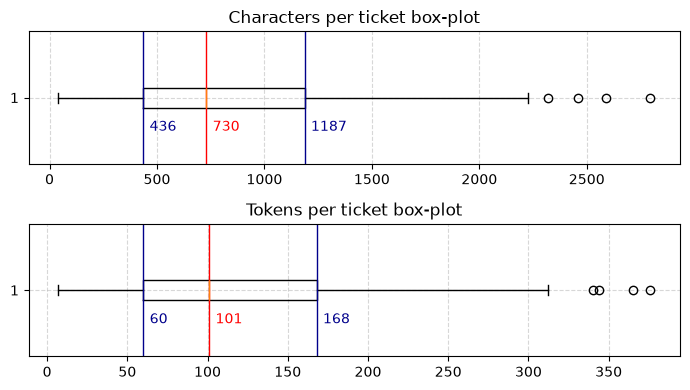

In [64]:
chars = cleaned_tickets_df["full_text"].str.len()
tokens = cleaned_tickets_df["full_text"].str.split(" ").str.len()

plt.clf()
fig, axs = plt.subplots(2, 1, figsize=(7, 4))

# Characters per ticket box-plot
axs[0].set_title("Characters per ticket box-plot")
axs[0].boxplot(chars, orientation="horizontal")
axs[0].grid(linestyle="--", alpha=0.5)

median_chars = chars.median()
axs[0].axvline(median_chars, color="red", linestyle="-", linewidth=1)
axs[0].text(median_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{median_chars:.0f}", color="red")

percentile_25_chars = chars.quantile(0.25)
axs[0].axvline(percentile_25_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_25_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_25_chars:.0f}", color="darkblue")

percentile_75_chars = chars.quantile(0.75)
axs[0].axvline(percentile_75_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_75_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_75_chars:.0f}", color="darkblue")

# Tokens per ticket box-plot
axs[1].set_title("Tokens per ticket box-plot")
axs[1].boxplot(tokens, orientation="horizontal")
axs[1].grid(linestyle="--", alpha=0.5)

median_tokens = tokens.median()
axs[1].axvline(median_tokens, color="red", linestyle="-", linewidth=1)
axs[1].text(median_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{median_tokens:.0f}", color="red")

percentile_25_tokens = tokens.quantile(0.25)
axs[1].axvline(percentile_25_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_25_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_25_tokens:.0f}", color="darkblue")

percentile_75_tokens = tokens.quantile(0.75)
axs[1].axvline(percentile_75_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_75_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_75_tokens:.0f}", color="darkblue")

plt.tight_layout()
plt.show()

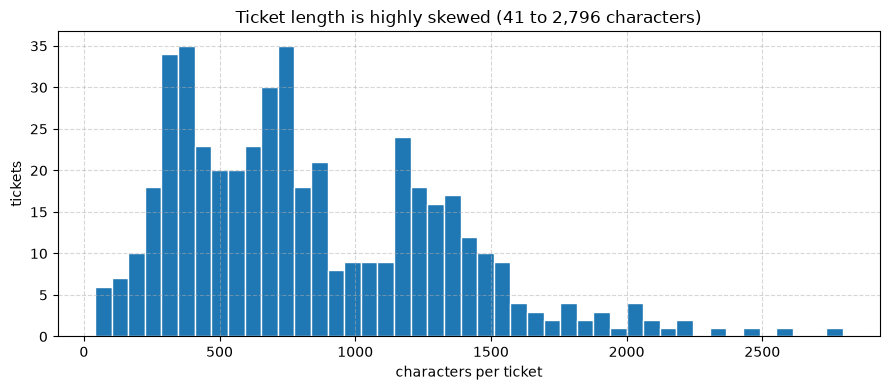

In [ ]:
plt.clf()
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(cleaned_tickets_df["full_text"].str.len(), bins=45, color="tab:blue", edgecolor="white")
ax.set_xlabel("characters per ticket")
ax.set_ylabel("tickets")
ax.set_title("Ticket length distribution")
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 2. Structural noise

Some noise is not a vocabulary problem and is better catalogued before vectorising: anonymisation
placeholders, HTML markup, and malformed rows.

In [ ]:
ANGLE_SPAN_RE = re.compile(r"<[^<>\n]{1,60}>")

angle_spans = full_text.map(ANGLE_SPAN_RE.findall)
span_counts = Counter(s.lower() for spans in angle_spans for s in spans)
placeholders = Counter({k: v for k, v in span_counts.items() if not k.startswith("<br")})
n_br = int(full_text.str.count(r"(?i)<br\s*/?>").sum())

print("Structural noise")
print(f"  angle-bracket spans, total   : {sum(span_counts.values())}")
print(f"    HTML <br> variants         : {n_br}  (in {full_text.str.contains(r'(?i)<br').sum()} tickets)")
print(f"    anonymisation placeholders : {sum(placeholders.values())}  "
      f"({len(placeholders)} distinct kinds)")
print(f"  tickets containing >=1 placeholder: "
      f"{angle_spans.map(lambda s: any(not x.lower().startswith('<br') for x in s)).sum()} / {N_DOCS}")

print("\n  Most common placeholders:")
for kind, count in placeholders.most_common(12):
    print(f"    {kind:<24}{count:>5}")
print("\n  The tokenizer discards < and >, but the words inside (name, tel_num, acc_num)")
print("  survive into the vocabulary. Section 3 shows how badly.\n")

# Malformed bodies: one ticket stores its content as a JSON string.
json_bodies = body_raw[body_raw.str.startswith(("{", "["))]
print(f"Bodies that are JSON rather than prose: {len(json_bodies)}")
for tid, text in json_bodies.items():
    print(f"  ticket {tid}: {text[:110]}...")

# Very short tickets: little signal, worth tracking downstream.
short = full_text[full_text.str.len() < 80].sort_values(key=lambda s: s.str.len())
print(f"\nTickets under 80 characters: {len(short)}")
for tid, text in short.items():
    print(f"  {tid} ({len(text):>3} chars): {text}")

### 3. Document frequency — the core boilerplate detector

Boilerplate is defined by **how many documents contain a term**, not by how often it occurs overall. A
word appearing once in every ticket is pure noise for any similarity measure; a word appearing ten times
in three tickets is highly informative. So use `binary=True` to measure document frequency directly.

scikit-learn ships no Portuguese stopword list (only `'english'`), so rather than importing one, the
stopword set is **derived from this corpus** — more defensible, and better fitted to support-email
register than a generic list would be.

In [ ]:
# binary=True gives document frequency (how many tickets contain the term),
# not term frequency. Boilerplate is defined by breadth, not by repetition.
df_counter = CountVectorizer(binary=True, lowercase=True, token_pattern=TOKEN_PATTERN)
df_matrix = df_counter.fit_transform(full_text)
vocab = np.array(df_counter.get_feature_names_out())
df_frac = np.asarray(df_matrix.sum(axis=0)).ravel() / N_DOCS

order = np.argsort(-df_frac)
doc_freq = pd.DataFrame({"term": vocab[order], "df_frac": df_frac[order]})

print(f"vocabulary size: {len(vocab)}")
for threshold in (0.5, 0.3, 0.1):
    print(f"  terms in >{threshold:.0%} of tickets: {(df_frac > threshold).sum()}")

print("\nTop 60 terms by document frequency:\n")
for i in range(0, 60, 3):
    print("".join(f"{doc_freq.term[j]:<18}{doc_freq.df_frac[j]:>6.1%}   "
                  for j in range(i, min(i + 3, 60))))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.arange(1, len(df_frac) + 1), np.sort(df_frac)[::-1], lw=1.6)
ax.set_xscale("log")
for threshold, colour in [(0.5, "tab:red"), (0.3, "tab:orange"), (0.1, "tab:green")]:
    ax.axhline(threshold, ls="--", lw=1, color=colour,
               label=f"DF = {threshold:.0%}  ({(df_frac > threshold).sum()} terms above)")
ax.set_xlabel("term rank (log scale)")
ax.set_ylabel("document frequency")
ax.set_title("Document-frequency decay: a short, very heavy boilerplate head")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Bucket the highest-DF terms by hand. This judgement is the actual deliverable of
# this section: it is what every cleaning rule below is justified against.
BUCKETS = {
    "grammatical stopword": """de para com que em do da por ao os as um uma no na se ou como
        mais este esta esse pela pelo sua seu minha meu nossa nosso me nos você isso não
        sem sobre está estou estamos ser tem pode esta quaisquer""".split(),
    "placeholder residue": "name tel_num acc_num email".split(),
    "support-email ceremony": """suporte cliente atendimento equipe time obrigado atenciosamente
        caro favor assistência ajuda escrevendo entrando contato mensagem espero encontre bem
        atenção rápida pronta imediata assunto resposta aguardo agradeço gentilmente""".split(),
    "genuine signal": """problema problemas resolver enfrentando serviço serviços solução
        resolução conta urgente configuração operações número software rede""".split(),
}
term_bucket = {t: b for b, terms in BUCKETS.items() for t in terms}

top_terms = doc_freq.head(80).copy()
top_terms["bucket"] = top_terms["term"].map(lambda t: term_bucket.get(t, "unclassified"))

print("Composition of the 80 most frequent terms:\n")
summary = (top_terms.groupby("bucket")
           .agg(n_terms=("term", "size"), mean_df=("df_frac", "mean"))
           .sort_values("n_terms", ascending=False))
print(summary.to_string(float_format=lambda v: f"{v:.3f}"))

print("\n\nTerms by bucket:\n")
for bucket in ["placeholder residue", "support-email ceremony", "genuine signal",
               "grammatical stopword", "unclassified"]:
    sub = top_terms[top_terms.bucket == bucket]
    if len(sub):
        listed = ", ".join(f"{r.term} ({r.df_frac:.0%})" for _, r in sub.iterrows())
        print(f"  {bucket.upper()} ({len(sub)}):\n    {listed}\n")

print("Note: 'problema' sits at 60% DF. In a support corpus every ticket describes a")
print("problem, so it is only weakly discriminative - borderline between the last two")
print("buckets. It is kept as signal because it still separates incidents from")
print("pre-sales enquiries and billing requests.")

### 4. Boilerplate is phrasal, not lexical

Unigram frequency understates the problem. The real ceremony in these tickets is multi-word —
*"espero que esta mensagem o encontre bem"*, *"aguardo sua resposta rápida"* — and no unigram filter can
remove a phrase while keeping its component words available elsewhere.

N-grams are ranked by `df x n_words` rather than by frequency alone, since that approximates how many
tokens each phrase would actually recover. A 7-word formula in 20% of tickets is worth more than a 3-word
one in 30%.

In [ ]:
ngram_counts = CountVectorizer(binary=True, ngram_range=(3, 8), min_df=0.05,
                               token_pattern=TOKEN_PATTERN).fit(full_text)
ngram_matrix = ngram_counts.transform(full_text)
ngrams = np.array(ngram_counts.get_feature_names_out())
ngram_df = np.asarray(ngram_matrix.sum(axis=0)).ravel() / N_DOCS
ngram_len = np.array([g.count(" ") + 1 for g in ngrams])

phrases = pd.DataFrame({"ngram": ngrams, "n_words": ngram_len, "df_frac": ngram_df})
# Rank by cleaning value, not raw frequency: a long phrase in 20% of tickets
# recovers more tokens than a 3-word phrase in 30%.
phrases["value"] = phrases["df_frac"] * phrases["n_words"]

print(f"{len(phrases)} distinct 3-8 word n-grams appear in at least 5% of tickets.\n")
print("Top 30 by cleaning value (df x n_words):\n")
for _, r in phrases.nlargest(30, "value").iterrows():
    print(f"  value={r.value:5.2f}  df={r.df_frac:6.2%}  n={r.n_words}  {r.ngram}")

print("\n\nLongest high-frequency formulas (n >= 6 words):\n")
for _, r in phrases[phrases.n_words >= 6].nlargest(12, "df_frac").iterrows():
    print(f"  df={r.df_frac:6.2%}  {r.ngram}")

### 5. Where boilerplate lives

Knowing *what* the boilerplate is does not yet tell us how to remove it safely. A global find-and-replace
for `"obrigado"` would also delete it from a sentence like *"Obrigado pela ajuda até agora, mas o problema
continua"* — destroying real content.

So measure **where** each boilerplate family occurs, as a fraction of document length. If greetings
cluster near 0.0 and signoffs near 1.0 while genuine signal spreads through the middle, then positional
rules (cut the first line, cut from the signoff to the end) are both safer and simpler than global
substitution. A signal control (`problema|erro|falha`) is included for contrast.

In [ ]:
# Probe families of boilerplate, plus one genuine-signal control for contrast.
PROBES = {
    "greeting: caro/prezado + suporte":   r"(?i)\b(caro|cara|prezad[oa]s?)\b[^.\n]{0,60}\b(suporte|atendimento|equipe|time|cliente)\b",
    "greeting: olá/saudações":            r"(?i)^\s*(ol[áa]|sauda[çc][õo]es)\b",
    "pleasantry: espero...encontre bem":  r"(?i)espero que (esta|este)[^.]{0,40}encontre[^.]{0,20}bem",
    "pleasantry: aguardo sua resposta":   r"(?i)aguard(o|ando|amos)[^.]{0,30}resposta",
    "pleasantry: obrigado pela atenção":  r"(?i)obrigad[oa][^.]{0,40}aten[çc][ãa]o",
    "signoff: atenciosamente":            r"(?i)\batenciosamente\b",
    "signoff: cordialmente/cumprimentos": r"(?i)\b(cordialmente|melhores cumprimentos|atentamente)\b",
    "closing: obrigado (standalone)":     r"(?i)\bobrigad[oa]\b",
    "placeholder: <name> etc":            r"<[^<>\n]{1,60}>",
    "CONTROL - signal: problema/erro":    r"(?i)\b(problema|erro|falha|defeito)\b",
}

positions, rows = {}, []
for label, pattern in PROBES.items():
    rx = re.compile(pattern, re.M)
    found, n_tickets = [], 0
    for text in full_text:
        matches = list(rx.finditer(text))
        if matches:
            n_tickets += 1
            found.extend(m.start() / len(text) for m in matches)
    if not found:
        continue
    found = np.array(found)
    positions[label] = found
    rows.append({"probe": label, "tickets": n_tickets, "df": n_tickets / N_DOCS,
                 "median_pos": np.median(found),
                 "first_15%": (found < 0.15).mean(), "last_25%": (found > 0.75).mean()})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(positions)
ax.boxplot([positions[l] for l in labels], orientation="horizontal",
           tick_labels=labels, widths=.6)
ax.axvspan(0, 0.15, color="tab:orange", alpha=.12, label="first 15% (greetings)")
ax.axvspan(0.75, 1.0, color="tab:red", alpha=.12, label="last 25% (signoffs)")
ax.set_xlabel("normalized position in document (0 = start, 1 = end)")
ax.set_title("Boilerplate is positionally segregated; genuine signal is not")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6. TF-IDF: boilerplate versus signal

Two questions here. First, does plain TF-IDF weighting rescue us — i.e. does the highest-weighted
vocabulary look like signal? Second, can the `max_df` parameter remove the boilerplate on its own,
which would make an explicit cleaning function unnecessary?

In [ ]:
tfidf = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=2,
                        token_pattern=TOKEN_PATTERN)
tfidf_matrix = tfidf.fit_transform(full_text)
features = np.array(tfidf.get_feature_names_out())
mean_weight = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
feat_df = np.asarray((tfidf_matrix > 0).sum(axis=0)).ravel() / N_DOCS

print("Ranked by document frequency          vs      ranked by mean TF-IDF weight\n")
for a, b in zip(np.argsort(-feat_df)[:25], np.argsort(-mean_weight)[:25]):
    print(f"  {features[a]:<24}{feat_df[a]:>6.1%}          {features[b]:<24}{mean_weight[b]:>7.4f}")

print("\n\nmax_df sweep - can a vectorizer parameter remove this on its own?\n")
for max_df in (1.0, 0.6, 0.4, 0.25):
    vocab = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=2,
                            max_df=max_df, token_pattern=TOKEN_PATTERN).fit(full_text).vocabulary_
    print(f"  max_df={max_df:<5}  vocabulary = {len(vocab):>6}")
print("\n  No. Tightening max_df from 1.0 to 0.25 drops only ~1% of the vocabulary,")
print("  because the ceremony is spread across many individually-unremarkable words.")
print("  Phrasal boilerplate needs an explicit cleaning function.")

### 7. Cleaning rules derived from the evidence

Every rule below traces to a measurement made above — nothing is included on intuition alone.

| # | Rule | Type | Evidence |
|---|---|---|---|
| 1 | Unwrap JSON-encoded bodies | structural | 1 ticket (3299) stores prose inside a JSON string |
| 2 | Replace `<br>` with newline | structural | 72 tags across 7 tickets |
| 3 | Strip `<placeholder>` spans | structural | 1,155 spans; `name` has DF 93.4%, `tel_num` 54.5%, `acc_num` 41.4% |
| 4 | Cut from the signoff marker to end | positional | signoff median position 0.966, p10 = 0.927 |
| 5 | Drop the leading salutation line | positional | greeting median position 0.061, 93.6% in first 15% |
| 6 | Remove pleasantry formulas | phrasal | `espero...encontre bem` DF 31.3%, `obrigado pela atenção` DF 31.7% |
| 7 | Repair orphaned punctuation | hygiene | removing spans leaves `"sob a conta ."` |
| 8 | Stopword list at vectorizer level | lexical | 26 terms with DF > 0.5 |

Two design decisions worth stating explicitly:

**Rules 4 and 5 are positional, not global.** The signoff cut only fires when the marker appears past 60%
of the document. Without that guard, a mid-body `"Obrigado pela ajuda até agora, mas o problema
continua..."` would silently truncate the actual complaint. The positional analysis is what makes the
0.60 threshold defensible rather than arbitrary.

**Stopwords are kept separate from text cleaning.** Text cleaning is destructive and belongs to the data
layer; stopword removal is a vectorizer parameter and stays reversible. Collapsing the two would make it
impossible to re-tokenise later with a different list.

In [ ]:
# --- Patterns, each traceable to a measurement above -------------------------
PLACEHOLDER_RE = re.compile(r"<[^<>\n]{1,60}>")
HTML_BR_RE = re.compile(r"(?i)<br\s*/?>")
HTML_TAG_RE = re.compile(r"<[^<>\n]{1,40}>")

GREETING_RE = re.compile(
    r"(?i)^\W*(car[oa]s?|prezad[oa]s?|ol[áa]|oi|sauda[çc][õo]es|bom dia|boa tarde|boa noite)"
    r"\b[^,\n]{0,90}[,:\n]")

SIGNOFF_RE = re.compile(
    r"(?i)\n?\s*\b(atenciosamente|cordialmente|atentamente|respeitosamente|"
    r"melhores cumprimentos|abra[çc]os|agradecemos por escolher|obrigad[oa])\b[\s\S]*$")

PLEASANTRY_RES = [
    re.compile(r"(?i)espero que (esta|este|o|a)\b[^.!?]{0,60}(encontre|encontrem)[^.!?]{0,25}bem[.!?]?"),
    re.compile(r"(?i)espero que (voc[êe]s?|o senhor|a senhora)\b[^.!?]{0,40}(esteja|estejam)[^.!?]{0,15}bem[.!?]?"),
    re.compile(r"(?i)aguard(o|ando|amos)[^.!?]{0,45}(resposta|retorno|assist[êe]ncia)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)agrade[çc](o|emos)[^.!?]{0,45}(antecipadamente|aten[çc][ãa]o|assist[êe]ncia)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)obrigad[oa][^.!?]{0,45}(aten[çc][ãa]o|assist[êe]ncia|apoio|suporte|compreens[ãa]o)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)\b(sinta-se [àa] vontade|fique [àa] vontade)\b[^.!?]{0,70}[.!?]?"),
    re.compile(r"(?i)\bpor favor,?\s*(me )?(avise|informe|deixe-me saber)\b[^.!?]{0,70}[.!?]?"),
]

DANGLING_PUNCT_RE = re.compile(r"\s+([.,;:!?])")
REPEAT_PUNCT_RE = re.compile(r"([.,;:])(\s*\1)+")
EMPTY_CLAUSE_RE = re.compile(r"(?<=[.:,])\s*[,;]")

# Only treat a signoff marker as a signoff if it appears late in the document.
# Justified by the positional analysis: the 10th percentile for signoff markers is
# 0.85+, so a 0.60 threshold will not cut a mid-body "obrigado".
SIGNOFF_MIN_POS = 0.60


def unwrap_json_body(text):
    """Ticket 3299 stores its body as a JSON string; recover the prose."""
    stripped = text.strip()
    if not stripped.startswith("{"):
        return text
    try:
        payload = json.loads(stripped)
    except (json.JSONDecodeError, ValueError):
        return text
    return " ".join(v for v in payload.values() if isinstance(v, str))


def tidy_punctuation(text):
    """Repair the orphaned punctuation left behind by removing spans."""
    text = DANGLING_PUNCT_RE.sub(r"\1", text)
    text = REPEAT_PUNCT_RE.sub(r"\1", text)
    text = EMPTY_CLAUSE_RE.sub("", text)
    return re.sub(r"\s+", " ", text).strip(" ,;:")


def clean_body(text):
    """Apply the rules in order: structural, then positional, then phrasal."""
    text = unwrap_json_body(text)
    text = HTML_BR_RE.sub("\n", text)
    text = PLACEHOLDER_RE.sub(" ", text)

    match = SIGNOFF_RE.search(text)
    if match and match.start() / max(len(text), 1) >= SIGNOFF_MIN_POS:
        text = text[:match.start()]

    text = GREETING_RE.sub(" ", text.lstrip())
    for pattern in PLEASANTRY_RES:
        text = pattern.sub(" ", text)
    return tidy_punctuation(text)


def clean_subject(text):
    """Subjects carry no greeting or signoff - only structural noise."""
    return tidy_punctuation(HTML_TAG_RE.sub(" ", text))

In [ ]:
# Apply the rules. Subject and body are cleaned separately: the positional rules
# (greeting / signoff) only make sense against the body's own start and end.
subject_clean = subject_raw.map(clean_subject)
body_clean = body_raw.map(clean_body)

# Safety net: if the rules stripped a body down to nothing, fall back to a
# structural-only clean so no ticket is ever lost.
body_fallback = body_raw.map(
    lambda t: tidy_punctuation(PLACEHOLDER_RE.sub(" ", HTML_BR_RE.sub(" ", unwrap_json_body(t))))
)
n_rescued = int((body_clean.str.len() < 20).sum())
body_clean = pd.Series(np.where(body_clean.str.len() < 20, body_fallback, body_clean),
                       index=body_clean.index)

clean_text = pd.Series(
    np.where(subject_clean == "", body_clean, subject_clean + ". " + body_clean),
    index=tickets_df.index, name="clean_text")

print(f"tickets rescued by the fallback: {n_rescued}")

# Stopwords are a *vectorizer* concern, kept separate from the destructive text
# cleaning above. scikit-learn ships no Portuguese list, so these are derived from
# the document-frequency buckets in section 3 rather than imported from elsewhere.
PT_FUNCTION_WORDS = """de para com que em do da por ao os as um uma no na nos nas
    se ou como mais este esta esse essa isso aos pela pelo pelos pelas sua seu suas seus
    minha meu minhas meus nossa nosso nossas nossos me lhe você vocês eu ele ela
    não sem sobre entre até após desde durante já também quando onde qual quais
    ser está estão estou estamos foi era tem têm ter há haver pode podem poderia poderiam
    quaisquer qualquer todo toda todos todas outro outra muito muita mesmo alguns""".split()

DOMAIN_CEREMONY = """suporte cliente clientes atendimento equipe time obrigado obrigada
    atenciosamente caro cara prezado prezada favor assistência ajuda escrevendo entrando
    contato mensagem email mail espero encontre bem atenção rápida pronta imediata
    assunto questão resposta responder aguardo aguardando agradeço agradecemos
    gentilmente cordialmente cumprimentos senhor senhora
    name tel_num acc_num email_address company_name order_num serial_num""".split()

STOPWORDS = sorted(set(PT_FUNCTION_WORDS) | set(DOMAIN_CEREMONY))
print(f"stopwords: {len(PT_FUNCTION_WORDS)} function words + "
      f"{len(DOMAIN_CEREMONY)} ceremony/placeholder terms = {len(STOPWORDS)} unique")

In [ ]:
def corpus_profile(series, stopwords=None):
    """Measure how much boilerplate remains and how separable the documents are."""
    counts = CountVectorizer(binary=True, token_pattern=TOKEN_PATTERN,
                             stop_words=stopwords).fit_transform(series)
    doc_frac = np.asarray(counts.sum(axis=0)).ravel() / counts.shape[0]

    tfidf_mat = TfidfVectorizer(sublinear_tf=True, min_df=2, token_pattern=TOKEN_PATTERN,
                                stop_words=stopwords).fit_transform(series)
    sim = (tfidf_mat @ tfidf_mat.T).toarray()
    n = sim.shape[0]
    mean_cos = (sim.sum() - np.trace(sim)) / (n * (n - 1))  # exclude the diagonal

    return {"vocab": counts.shape[1],
            "df>0.5": int((doc_frac > 0.5).sum()),
            "df>0.3": int((doc_frac > 0.3).sum()),
            "df>0.1": int((doc_frac > 0.1).sum()),
            "mean_chars": series.str.len().mean(),
            "mean_cos": mean_cos}


impact = pd.DataFrame({
    "1. raw (subject + body)": corpus_profile(full_text),
    "2. + text cleaning": corpus_profile(clean_text),
    "3. + stopword removal": corpus_profile(clean_text, STOPWORDS),
}).T
impact["char_reduction"] = 1 - impact["mean_chars"] / impact.iloc[0]["mean_chars"]

print("Cleaning impact\n")
print(impact.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nThe decisive metric is mean_cos: lower means documents are more distinguishable")
print("from one another, which is the whole point of removing shared boilerplate.")

In [ ]:
# What signal survives? Top TF-IDF terms after cleaning AND stopword removal.
signal_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                             token_pattern=TOKEN_PATTERN, stop_words=STOPWORDS)
signal_mat = signal_vec.fit_transform(clean_text)
signal_terms = np.array(signal_vec.get_feature_names_out())
signal_weight = np.asarray(signal_mat.mean(axis=0)).ravel()

print("Top 30 TF-IDF terms after cleaning + stopword removal:\n")
for rank, i in enumerate(np.argsort(-signal_weight)[:30], start=1):
    print(f"  {rank:>2}. {signal_terms[i]:<28}{signal_weight[i]:.4f}")

### 8. Qualitative validation

Metrics can improve while the text is quietly being destroyed, so inspect the result directly. The sample
below deliberately spans the edge cases found in section 2 — the longest and shortest tickets, the
HTML-formatted one, and the JSON-malformed one — and includes an explicit guard against over-cleaning.

In [ ]:
# Qualitative validation: read the cleaning, do not just trust the metrics.
# Sample deliberately spans the edge cases surfaced in section 2.
SAMPLES = {
    523: "long, highly formal ticket",
    63: "HTML <br> formatting",
    3299: "JSON-malformed body",
    2416: "shortest ticket (41 chars)",
    88: "placeholder mid-sentence",
    1052: "outbound agent reply (data-quality issue)",
}

for tid, why in SAMPLES.items():
    before, after = full_text[tid], clean_text[tid]
    print(f"--- ticket {tid} | {why}")
    print(f"    {len(before)} -> {len(after)} chars ({1 - len(after)/len(before):.0%} removed)")
    print(f"    RAW  : {before[:250]}")
    print(f"    CLEAN: {after[:250]}\n")

# Over-cleaning guard: a short ticket must never be reduced to nothing.
too_short = clean_text[clean_text.str.len() < 30]
print(f"cleaned documents under 30 chars : {len(too_short)}")
print(f"empty cleaned documents          : {(clean_text.str.len() == 0).sum()}")
if len(too_short):
    print("\nWARNING - rules may be too aggressive for:")
    for tid, t in too_short.items():
        print(f"  {tid}: {t!r}")

## Findings

**The corpus is heavily formulaic.** 26 terms appear in more than half of all 473 tickets. These carry
almost no discriminative information but consume a large share of every document vector.

**Anonymisation placeholders are the single worst offender.** `name` is the *second most frequent term in
the entire corpus*, appearing in 93.4% of tickets — ahead of `suporte` (89.2%) and every real content word.
`tel_num` (54.5%) and `acc_num` (41.4%) follow. The angle brackets are discarded by the tokenizer, but the
words inside survive and pollute the vocabulary. There are 1,155 placeholder spans across 41 distinct kinds.

**The boilerplate is phrasal, not lexical.** The highest-value cleaning targets are multi-word formulas:
`espero que esta mensagem ... encontre bem` (22.4% of tickets), `suporte ao cliente` (66.8%),
`estou escrevendo para` (46.7%), `obrigado pela sua atenção` (24.5%). No amount of unigram filtering
removes these. The `max_df` sweep confirms it directly: dropping `max_df` from 1.0 to 0.25 shrinks the
vocabulary by only 95 terms out of 7,910 (1.2%), because the ceremony is spread across many
individually-unremarkable words. **An explicit cleaning function is required; vectorizer parameters are
not sufficient.**

**Boilerplate is positionally segregated, which makes it safe to strip.** Greetings sit at median position
0.061 with 93.6% of occurrences inside the first 15% of the document. Signoffs sit at median 0.966 with
100% of occurrences in the last 25%. By contrast the signal probe (`problema|erro|falha`) sits at median
0.372 and is spread through the middle. This separation is what licenses positional rules — cutting from
the signoff marker to the end, and dropping the leading salutation — rather than global find-and-replace,
which would delete legitimate mid-body text.

**The cleaning works.** Applying the rules and the derived stopword list:

| metric | raw | + cleaning | + stopwords |
|---|---|---|---|
| terms with DF > 0.5 | 26 | 14 | **1** |
| terms with DF > 0.3 | 59 | 36 | **4** |
| mean pairwise cosine | 0.110 | 0.092 | **0.049** |
| mean length (chars) | 834 | 687 | 687 |

Mean pairwise cosine similarity falling from 0.110 to 0.049 is the meaningful result: documents became
**more distinguishable from one another**, which is the entire purpose of the exercise. Vocabulary only
shrinks 3385 → 3200, confirming that content words were preserved while ceremony was removed.

The surviving top-weighted terms are `problema, aws, serviço, impressora, rede, roteador, conectividade,
configuração, gerenciamento` — product and intent vocabulary, with no ceremony left.

### Data-quality issues found

- **Ticket 3299** — the body is a raw JSON string (`{"greeting": ..., "body": ..., "closing": ...}`)
  rather than plain text. Handled by `unwrap_json_body()`; it is the only such row.
- **Tickets 46 and 1052** — these are outbound *agent replies*, not customer tickets
  ("Sentimos muito ao saber sobre o atraso...", "Recebemos o seu relatório..."). They do not belong in a
  corpus of inbound requests and should be reviewed before any downstream modelling.
- **7 tickets use HTML `<br>`** instead of newlines (72 tags total) — e.g. 63, 600, 1381.
- **4 tickets are under 80 characters** (2416, 3902, 2908, 3849), the shortest being 41. These carry very
  little signal and are worth tracking separately downstream.
- **54 tickets have no subject**, so the analysis field falls back to the body alone.

### Recommended configuration for downstream work

Use `clean_text` as the model input, with `STOPWORDS` passed to the vectorizer. Keep the two steps
separate — text cleaning is destructive and belongs in the data layer, whereas stopword removal is a
vectorizer concern and should stay reversible.